In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("./data_ts/monthly-beer-production-in-austr.csv").head(200)

In [3]:
df

,Month,Monthly beer production
0,1956-01,93.2
1,1956-02,96.0
2,1956-03,95.2
3,1956-04,77.1
4,1956-05,70.9
...,...,...
195,1972-04,120.0
196,1972-05,140.5
197,1972-06,116.2
198,1972-07,121.4


In [4]:
df = df.rename(columns={
    "Month" : "timestamp",
    "Monthly beer production" : "value"
})

In [5]:
df

,timestamp,value
0,1956-01,93.2
1,1956-02,96.0
2,1956-03,95.2
3,1956-04,77.1
4,1956-05,70.9
...,...,...
195,1972-04,120.0
196,1972-05,140.5
197,1972-06,116.2
198,1972-07,121.4


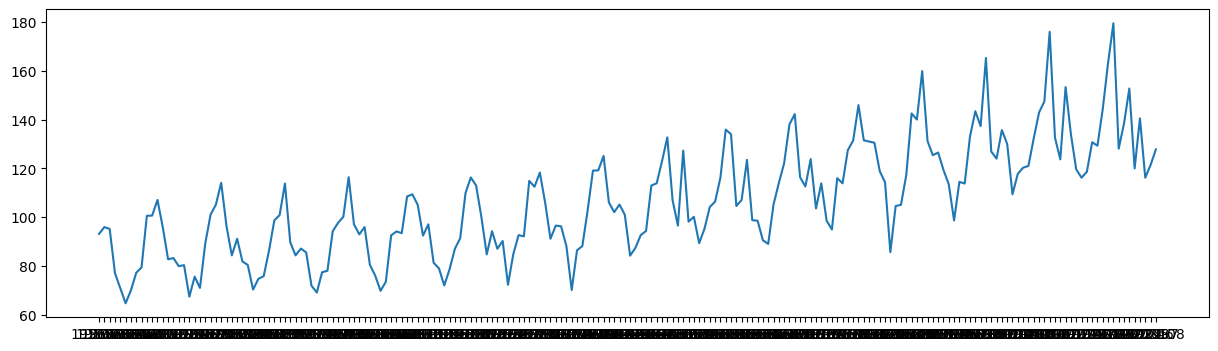

In [6]:
plt.figure(figsize=(15, 4))
plt.plot(df["timestamp"], df["value"])

In [25]:
!which pip

/Users/hanif/miniconda3/bin/pip


In [9]:
import sys

In [10]:
sys.prefix

'/Users/hanif/miniconda3/envs/mlseq'

In [11]:
# !/Users/hanif/miniconda3/envs/mlseq/bin/pip install statsmodels

  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 1.5 MB/s eta 0:00:00m eta 0:00:0136m0:00:010m
Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)


In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [24]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [26]:
df

,timestamp,value
0,1956-01-01,93.2
1,1956-02-01,96.0
2,1956-03-01,95.2
3,1956-04-01,77.1
4,1956-05-01,70.9
...,...,...
195,1972-04-01,120.0
196,1972-05-01,140.5
197,1972-06-01,116.2
198,1972-07-01,121.4


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  200 non-null    datetime64[ns]
 1   value      200 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.3 KB


In [29]:
series = df.set_index("timestamp")

In [30]:
decompose = seasonal_decompose(series)

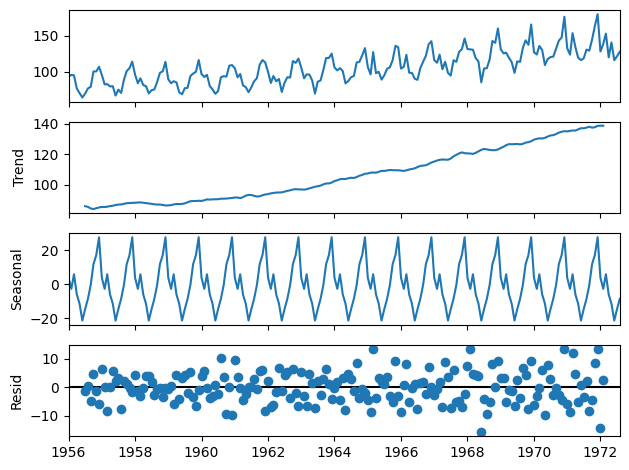

In [34]:
decompose.plot()
plt.show()

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

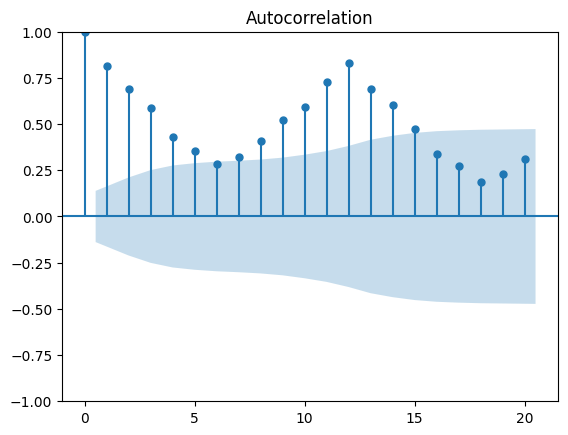

In [40]:
plot_acf(series, lags=20)
plt.show()

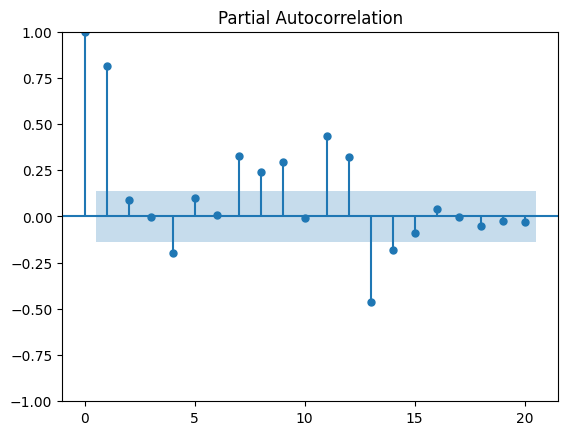

In [41]:
plot_pacf(series, lags=20)
plt.show()

In [42]:
from statsmodels.tsa.stattools import adfuller, kpss

In [43]:
adfuller(series)

(2.012899487898074,
 0.9986894800360682,
 11,
 188,
 {'1%': -3.465620397124192,
  '5%': -2.8770397560752436,
  '10%': -2.5750324547306476},
 1204.2179834922651)

In [44]:
kpss(series)

/var/folders/sv/jrcrjk6s3y59jsqwnt5d73y40000gn/T/ipykernel_1251/857750690.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss(series)


(2.12593781150066,
 0.01,
 8,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})